In [ ]:
!pip install tensorflow torch torchvision transformers tqdm datasets pillow

In [2]:
# =============================================================================
#  Image Normalization — Animals-10 Dataset
#  · Converts to RGB
#  · Resizes to TARGET_SIZE
#  · Saves organized by class in subfolders
# =============================================================================
!pip install -q datasets pillow tqdm

import io
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from datasets import load_dataset
from PIL import Image

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_SIZE  = (90, 90)
DATA_DIR     = Path("/content/animals10/normalized-224")
JPEG_QUALITY = 92
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
ds = load_dataset("34data/animal-10", split="train")
print(f"  → {len(ds):,} examples\n")

counters  = defaultdict(int)
failed    = 0

for sample in tqdm(ds, desc="Normalizing", unit="img"):
    try:
        # ✅ bytes → PIL.Image
        img = Image.open(io.BytesIO(sample["image"])).convert("RGB")
        img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

        # Clase: "v12/Real/.../cane/imagen.jpg" → "cane"
        parts = sample["filename"].replace("\\", "/").split("/")
        cls   = parts[-2] if len(parts) >= 2 else "unknown"
        if cls == "unknown":
            raise ValueError(f"Bad filename: {sample['filename']}")

        out_path = DATA_DIR / cls / f"{counters[cls]:06d}.jpg"
        out_path.parent.mkdir(exist_ok=True)
        img.save(out_path, format="JPEG", quality=JPEG_QUALITY)
        counters[cls] += 1

    except Exception as e:
        failed += 1

# ── Reporte ───────────────────────────────────────────────────────────────────
total = sum(counters.values())
print(f"\n{'═'*50}")
print(f"Saved  : {total:,}  |  Failed : {failed:,}")
print(f"\nClass distribution:")
for cls, n in sorted(counters.items(), key=lambda x: -x[1]):
    print(f"  {cls:<20} {n:>6,} images")

print("\nVerification (size + mode):")
for cls in sorted(counters):
    first = next((DATA_DIR / cls).glob("*.jpg"))
    with Image.open(first) as im:
        print(f"  {cls:<20} {im.size}  mode={im.mode}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

animal-10_0001.parquet:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

animal-10_0016.parquet:   0%|          | 0.00/145M [00:00<?, ?B/s]

...

animal-10_0026.parquet:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26177 [00:00<?, ? examples/s]

  → 26,177 examples



Normalizing:   0%|          | 0/26177 [00:00<?, ?img/s]


══════════════════════════════════════════════════
Saved  : 26,177  |  Failed : 0

Class distribution:
  cane                  4,863 images
  ragno                 4,821 images
  gallina               3,098 images
  cavallo               2,623 images
  farfalla              2,112 images
  mucca                 1,865 images
  scoiattolo            1,861 images
  pecora                1,820 images
  gatto                 1,668 images
  elefante              1,446 images

Verification (size + mode):
  cane                 (90, 90)  mode=RGB
  cavallo              (90, 90)  mode=RGB
  elefante             (90, 90)  mode=RGB
  farfalla             (90, 90)  mode=RGB
  gallina              (90, 90)  mode=RGB
  gatto                (90, 90)  mode=RGB
  mucca                (90, 90)  mode=RGB
  pecora               (90, 90)  mode=RGB
  ragno                (90, 90)  mode=RGB
  scoiattolo           (90, 90)  mode=RGB


#EfficientNetV2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input


# Configuration
IMG_SIZE = (90, 90)          # EfficientNetV2S default
BATCH_SIZE = 32
NUM_CLASSES = 10               # ← CHANGE THIS to your number of classes
EPOCHS = 10

# Data loading
train_ds = keras.utils.image_dataset_from_directory(
    "/content/animals10/normalized-224",
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = keras.utils.image_dataset_from_directory(
    "/content/animals10/normalized-224",
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=0.2,
    subset="training",
    seed=42
)

# Apply preprocessing (EfficientNetV2 expects [0, 255] range, but includes its own preprocess)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(  lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# Load base model
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg"           # global average pooling by default
)

# Freeze the base (feature extraction first)
base_model.trainable = False

# Build model
inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train (feature extraction phase)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)



Found 26177 files belonging to 10 classes.
Using 20942 files for training.
Found 26177 files belonging to 10 classes.
Using 20942 files for training.
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1464s 2s/step - accuracy: 0.7372 - loss: 0.8839 - val_accuracy: 0.8767 - val_loss: 0.3895
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1428s 2s/step - accuracy: 0.8624 - loss: 0.4224 - val_accuracy: 0.8879 - val_loss: 0.3474
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1331s 2s/step - accuracy: 0.8775 - loss: 0.3788 - val_accuracy: 0.8944 - val_loss: 0.3268
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1372s 2s/step - accuracy: 0.8793 - loss: 0.3668 - val_accuracy: 0.8985 - val_loss: 0.3142
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1461s 2s/step - accuracy: 0.8862 - loss: 0.3524 - val_accuracy: 0.9020 - val_loss: 0.2992
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 1361s 2s/step - accuracy: 0.8857 - loss: 0.3439 - val_accuracy: 0.9033 - val_loss: 0.2939
Epoch 7/10
655/655 

In [ ]:
model.save('/content/models/efficientnetv2s.h5')

#ConvNeXt

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input

import numpy as np
import matplotlib.pyplot as plt
import os, zipfile, json

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR       = "/content/animals10/normalized-224"
CHECKPOINT_PATH = "/content/best_convnext.keras"
EXPORT_DIR     = "/content/convnext_animals10"
ZIP_PATH       = "/content/convnext_animals10.zip"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 10
EPOCHS_HEAD = 10     # Train only the head (base frozen)
EPOCHS_FINE = 6      # Fine-tune last N layers of base
UNFREEZE_FROM = -30  # Unfreeze last 30 layers during fine-tuning
LR_HEAD = 5e-4
LR_FINE = 1e-5
PATIENCE    = 3
VAL_SPLIT   = 0.1

# Mixed precision for faster training on GPU/TPU
mixed_precision.set_global_policy("mixed_float16")
print(f"✅ Mixed precision : {mixed_precision.global_policy().name}")
print(f"   GPUs available  : {len(tf.config.list_physical_devices('GPU'))}")

# ─────────────────────────────────────────────────────────────────────────────
#  LABEL MAPPING  (Animals-10 folder names → English)
# ─────────────────────────────────────────────────────────────────────────────
LABEL_MAP = {
    "cane":       "dog",
    "cavallo":    "horse",
    "elefante":   "elephant",
    "farfalla":   "butterfly",
    "gallina":    "chicken",
    "gatto":      "cat",
    "mucca":      "cow",
    "pecora":     "sheep",
    "ragno":      "spider",
    "scoiattolo": "squirrel",
}

# Build index → English name mapping (sorted alphabetically, same as Keras)
raw_classes  = sorted(os.listdir(DATA_DIR))          # folder names
english_names = [LABEL_MAP.get(c, c) for c in raw_classes]
print(f"\n Class mapping  : {dict(zip(raw_classes, english_names))}")

# ─────────────────────────────────────────────────────────────────────────────
#  DATASET  (single split, augmentation only on train)
# ─────────────────────────────────────────────────────────────────────────────
def build_datasets():
    common = dict(
        directory=DATA_DIR,
        label_mode="categorical",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        seed=42,
    )
    train_raw = keras.utils.image_dataset_from_directory(subset="training",   **common)
    val_raw   = keras.utils.image_dataset_from_directory(subset="validation", **common)
    return train_raw, val_raw

train_raw, val_raw = build_datasets()
N_TRAIN = train_raw.cardinality().numpy() * BATCH_SIZE
N_VAL   = val_raw.cardinality().numpy()   * BATCH_SIZE
print(f"\n Dataset   : ~{N_TRAIN:,} train | ~{N_VAL:,} val")

# Data augmentation (applied only to train, inside tf.data pipeline)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def prepare_train(x, y):
    x = augment(x, training=True)
    return preprocess_input(x), y

def prepare_val(x, y):
    return preprocess_input(x), y

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (train_raw
            .map(prepare_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds   = (val_raw
            .map(prepare_val, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

# ─────────────────────────────────────────────────────────────────────────────
#  MODEL
# ─────────────────────────────────────────────────────────────────────────────
base_model = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    pooling="avg",
)
base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(256, activation="gelu")(x)       # Extra dense head
x       = layers.Dropout(0.2)(x)
# Cast to float32 before softmax (required with mixed precision)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="ConvNeXtBase_Animals10")
model.summary(line_length=80)

# ─────────────────────────────────────────────────────────────────────────────
#  CALLBACKS
# ─────────────────────────────────────────────────────────────────────────────
def make_callbacks(monitor="val_accuracy"):
    return [
        keras.callbacks.ModelCheckpoint(
            CHECKPOINT_PATH,
            monitor=monitor,
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

# ─────────────────────────────────────────────────────────────────────────────
#  PHASE 1 — Train head only
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  PHASE 1 — Head training (base frozen)")
print("═"*60)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_HEAD, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks(),
)

# ─────────────────────────────────────────────────────────────────────────────
#  PHASE 2 — Fine-tuning (unfreeze last layers)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print(f"  PHASE 2 — Fine-tuning (last {abs(UNFREEZE_FROM)} base layers)")
print("═"*60)

base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

frozen   = sum(not l.trainable for l in base_model.layers)
unfrozen = sum(l.trainable     for l in base_model.layers)
print(f"   Frozen layers   : {frozen}")
print(f"   Unfrozen layers : {unfrozen}")

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=make_callbacks(),
)

# ─────────────────────────────────────────────────────────────────────────────
#  METRICS PLOT
# ─────────────────────────────────────────────────────────────────────────────
def merge_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (k_train, k_val), title in zip(
    axes,
    [("loss", "val_loss"), ("accuracy", "val_accuracy")],
    ["Loss", "Accuracy"],
):
    y_train = merge_history(history1, history2, k_train)
    y_val   = merge_history(history1, history2, k_val)
    epochs  = range(1, len(y_train) + 1)
    split   = len(history1.history[k_train])

    ax.plot(epochs, y_train, "o-", label="Train", color="royalblue")
    ax.plot(epochs, y_val,   "o-", label="Val",   color="tomato")
    ax.axvline(split + 0.5, color="gray", linestyle="--", alpha=0.6, label="Fine-tune start")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("ConvNeXtBase — Animals10", fontsize=14)
plt.tight_layout()
plt.savefig("/content/training_metrics.png", dpi=100)
plt.show()

best_val_acc = max(merge_history(history1, history2, "val_accuracy"))
print(f"\n🏆 Best val accuracy : {best_val_acc*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
#  SAVE MODEL + LABEL MAP
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs(EXPORT_DIR, exist_ok=True)

# Load the best checkpoint saved during training
best_model = keras.models.load_model(CHECKPOINT_PATH)
best_model.save(os.path.join(EXPORT_DIR, "model.keras"))

# Save label map as JSON
label_info = {
    "index_to_label": {str(i): name for i, name in enumerate(english_names)},
    "label_to_index": {name: i for i, name in enumerate(english_names)},
    "raw_to_english": LABEL_MAP,
    "num_classes": NUM_CLASSES,
    "img_size": list(IMG_SIZE),
}
with open(os.path.join(EXPORT_DIR, "label_map.json"), "w") as f:
    json.dump(label_info, f, indent=2)

# Copy metrics plot
import shutil
shutil.copy("/content/training_metrics.png", EXPORT_DIR)

print(f"✅ Model saved to  : {EXPORT_DIR}")

# ─────────────────────────────────────────────────────────────────────────────
#  ZIP MODEL
# ─────────────────────────────────────────────────────────────────────────────
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(EXPORT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname   = os.path.relpath(full_path, "/content")
            zf.write(full_path, arcname)

print(f"✅ Zipped to        : {ZIP_PATH}")

try:
    from google.colab import files
    files.download(ZIP_PATH)
    print("⬇️  Download started automatically")
except ImportError:
    print(f"ℹ️  Not running in Colab — find your file at: {ZIP_PATH}")

# ─────────────────────────────────────────────────────────────────────────────
#  INFERENCE HELPER
# ─────────────────────────────────────────────────────────────────────────────
def predict(image_path: str, top_k: int = 3) -> dict:
    """
    Predict the animal class of a single image.
    Returns a dict of {animal_name: probability_string}.
    """
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = preprocess_input(np.expand_dims(arr, 0))

    probs   = best_model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    results = {english_names[i]: f"{probs[i]*100:.2f}%" for i in top_idx}

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(keras.utils.load_img(image_path, target_size=IMG_SIZE))
    axes[0].axis("off"); axes[0].set_title("Input image")

    names  = list(results.keys())
    values = [float(v[:-1]) for v in results.values()]
    bars   = axes[1].barh(names, values, color="royalblue")
    axes[1].set_xlabel("Probability (%)")
    axes[1].set_title(f"Top-{top_k} predictions")
    axes[1].bar_label(bars, labels=list(results.values()), padding=4)
    plt.tight_layout(); plt.show()

    return results

# Example usage:
# predict("/path/to/your/image.jpg")

# Later fine-tuning example:
# base_model.trainable = True
# model.compile(optimizer=keras.optimizers.AdamW(1e-5), loss=..., metrics=...)
# model.fit(...)

✅ Mixed precision : mixed_float16
   GPUs available  : 1

 Class mapping  : {'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant', 'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat', 'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'}
Found 26177 files belonging to 10 classes.
Using 23560 files for training.
Found 26177 files belonging to 10 classes.
Using 2617 files for validation.

 Dataset   : ~23,584 train | ~2,624 val
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ConvNeXtBase_Animals10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ convnext_tiny (Functional)        │ (None, 768)              │    27,820,128 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 768)              │         3,072 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 768)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       196,864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 28,022,634 (106.90 MB)

 Trainable params: 200,970 (785.04 KB)

 Non-trainable params: 27,821,664 (106.13 MB)


════════════════════════════════════════════════════════════
  PHASE 1 — Head training (base frozen)
════════════════════════════════════════════════════════════
Epoch 1/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8473 - loss: 0.5030
Epoch 1: val_accuracy improved from -inf to 0.96141, saving model to /content/best_convnext.keras
737/737 ━━━━━━━━━━━━━━━━━━━━ 587s 688ms/step - accuracy: 0.8474 - loss: 0.5027 - val_accuracy: 0.9614 - val_loss: 0.1241 - learning_rate: 5.0000e-04
Epoch 2/10
736/737 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9382 - loss: 0.2015
Epoch 2: val_accuracy improved from 0.96141 to 0.96561, saving model to /content/best_convnext.keras
737/737 ━━━━━━━━━━━━━━━━━━━━ 362s 490ms/step - accuracy: 0.9382 - loss: 0.2015 - val_accuracy: 0.9656 - val_loss: 0.1135 - learning_rate: 5.0000e-04
Epoch 3/10
736/737 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9494 - loss: 0.1650
Epoch 3: val_accuracy did not improve from 0.96561
737/737 ━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

#Vision Transformer (ViT)

✅ Device : cuda
   GPU          : Tesla T4
   VRAM         : 15.6 GB
   AMP          : True


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]


✅ Dataset      : 26,177 images → Train 23,559 | Val 2,618
   Clases       : ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    Checkpoint Saved (val_loss=0.5275)


Epoch  5/10 | Train → loss: 0.5208  acc: 99.28% | Val   → loss: 0.5285  acc: 98.89% | ⏱ 205s
   No improve 1/3


Epoch  6/10 | Train → loss: 0.5201  acc: 99.30% | Val   → loss: 0.5290  acc: 98.85% | ⏱ 204s
   No improve 2/3


Epoch  7/10 | Train → loss: 0.5182  acc: 99.41% | Val   → loss: 0.5293  acc: 98.93% | ⏱ 204s
   No improve 3/3

🛑 Early stopping. Best epoch: 4


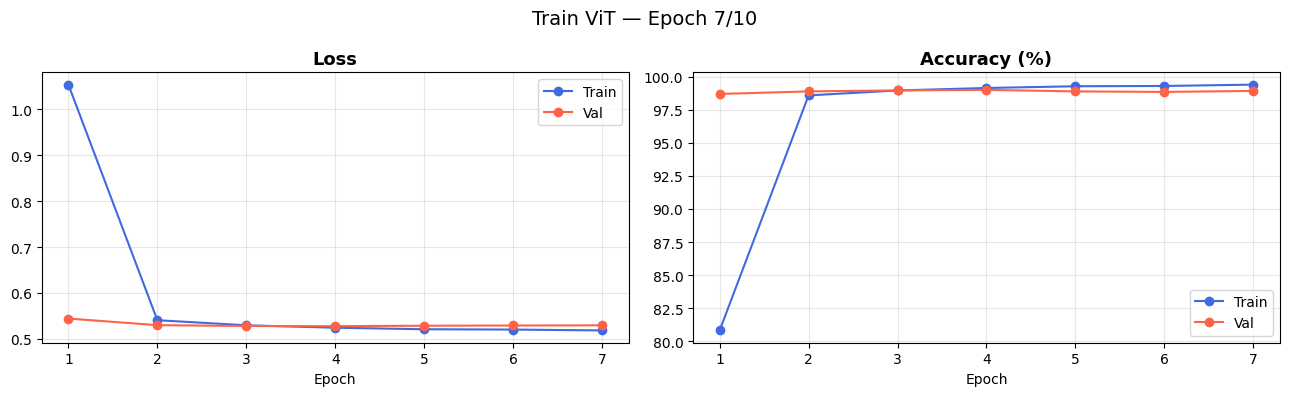


✅ Training complete in 26.1 min


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model SAVED in : /content/my_vit_animals10
   Best epoch        : 4
   Best val_loss     : 0.5275
   Best val_acc      : 99.01%


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast
from transformers import ViTImageProcessor, ViTForImageClassification, get_linear_schedule_with_warmup
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, time

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
MODEL_NAME      = "google/vit-base-patch16-224"
DATA_DIR        = "/content/animals10/normalized-224"
CHECKPOINT_DIR  = "/content/checkpoints"
FINAL_MODEL_DIR = "/content/my_vit_animals10"

NUM_CLASSES  = 10
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
TRAIN_RATIO  = 0.9
FROZEN_LAYERS = 6
PATIENCE     = 3
MIN_DELTA    = 1e-4

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

os.makedirs(CHECKPOINT_DIR,  exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print(f"✅ Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU          : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"   AMP          : {USE_AMP}")

# ─────────────────────────────────────────────────────────────────────────────
#  DATASET
# ─────────────────────────────────────────────────────────────────────────────
processor  = ViTImageProcessor.from_pretrained(MODEL_NAME)
IMAGE_SIZE = processor.size if isinstance(processor.size, int) \
             else processor.size.get("shortest_edge", 224)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

full_train  = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_val    = datasets.ImageFolder(DATA_DIR, transform=val_transform)
CLASS_NAMES = full_train.classes

n_total = len(full_train)
n_train = int(TRAIN_RATIO * n_total)
indices = torch.randperm(n_total).tolist()

train_loader = DataLoader(Subset(full_train, indices[:n_train]),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(Subset(full_val, indices[n_train:]),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"\n✅ Dataset      : {n_total:,} images → Train {n_train:,} | Val {n_total-n_train:,}")
print(f"   Clases       : {CLASS_NAMES}")

# ─────────────────────────────────────────────────────────────────────────────
#  MODEL
# ─────────────────────────────────────────────────────────────────────────────
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
    id2label={i: c for i, c in enumerate(CLASS_NAMES)},
    label2id={c: i for i, c in enumerate(CLASS_NAMES)},
).to(DEVICE)

for layer in model.vit.encoder.layer[:FROZEN_LAYERS]:
    for p in layer.parameters():
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n✅ Params   : {trainable:,} / {total:,}  ({100*trainable/total:.1f}% entrenables)")

optimizer = AdamW([
    {"params": model.vit.encoder.layer[FROZEN_LAYERS:].parameters(), "lr": LR},
    {"params": model.classifier.parameters(), "lr": LR * 5},
], weight_decay=WEIGHT_DECAY)

num_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * num_steps),
    num_training_steps=num_steps,
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler(enabled=USE_AMP)

# ─────────────────────────────────────────────────────────────────────────────
#  EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience, min_delta, path):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.best_loss  = float("inf")
        self.best_epoch = 0
        self.counter    = 0

    def step(self, val_loss, model, processor, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            model.save_pretrained(self.path)
            processor.save_pretrained(self.path)
            print(f"    Checkpoint Saved (val_loss={val_loss:.4f})")
            return False
        self.counter += 1
        print(f"   No improve {self.counter}/{self.patience}")
        return self.counter >= self.patience

early_stopping = EarlyStopping(PATIENCE, MIN_DELTA, CHECKPOINT_DIR)

# ─────────────────────────────────────────────────────────────────────────────
#  VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def plot_history(epoch):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    rng = range(1, epoch + 2)
    for ax, (k1, k2), title in zip(
        axes,
        [("train_loss", "val_loss"), ("train_acc", "val_acc")],
        ["Loss", "Accuracy (%)"],
    ):
        ax.plot(rng, history[k1], "o-", label="Train", color="royalblue")
        ax.plot(rng, history[k2], "o-", label="Val",   color="tomato")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"Train ViT — Epoch {epoch+1}/{EPOCHS}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CHECKPOINT_DIR}/metrics_epoch{epoch+1}.png", dpi=90)
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
#  TRAINING
# ─────────────────────────────────────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="Train" if train else "Val  ",
                                   leave=False, unit="batch"):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=USE_AMP):
                logits = model(images).logits
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


print("\n Beginning Training...\n")
t_total = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"  ].append(val_loss)
    history["train_acc" ].append(train_acc)
    history["val_acc"   ].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train → loss: {train_loss:.4f}  acc: {train_acc:.2f}% | "
          f"Val   → loss: {val_loss:.4f}  acc: {val_acc:.2f}% | "
          f"⏱ {time.time()-t0:.0f}s")


    if early_stopping.step(val_loss, model, processor, epoch):
        print(f"\n🛑 Early stopping. Best epoch: {early_stopping.best_epoch+1}")
        break
plot_history(epoch)
print(f"\n✅ Training complete in {(time.time()-t_total)/60:.1f} min")

# ─────────────────────────────────────────────────────────────────────────────
#  SAVE BEST MODEL
# ─────────────────────────────────────────────────────────────────────────────
best_model = ViTForImageClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
best_model.save_pretrained(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)

print(f"\n✅ Model SAVED in : {FINAL_MODEL_DIR}")
print(f"   Best epoch        : {early_stopping.best_epoch+1}")
print(f"   Best val_loss     : {early_stopping.best_loss:.4f}")
print(f"   Best val_acc      : {max(history['val_acc']):.2f}%")